In [1]:
import time
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import TensorDataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler


In [2]:
df = pd.read_csv('../data/gym_churn_us.csv')
df['caida_frecuencia'] = df['Avg_class_frequency_total'] - df['Avg_class_frequency_current_month']
X = df.drop(columns=['Churn', 'Avg_class_frequency_total', 'Phone', 'gender'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
columnas_campana = ['Age','Avg_class_frequency_current_month', 'caida_frecuencia']
columnas_sesgadas_o_fijas = ['Lifetime', 'Avg_additional_charges_total', 'Contract_period', 'Month_to_end_contract']

In [4]:
preprocesador = ColumnTransformer(
    transformers=[
        ('estandarizacion', StandardScaler(), columnas_campana),
        ('normalizacion', MinMaxScaler(), columnas_sesgadas_o_fijas)
    ],
    remainder='passthrough' 
)

In [5]:
X_train_escalado = preprocesador.fit_transform(X_train)
X_test_escalado = preprocesador.transform(X_test)

In [6]:
ros = RandomOverSampler()
X_ros, y_ros = ros.fit_resample(X_train_escalado, y_train)

rus = RandomUnderSampler()
X_rus, y_rus = rus.fit_resample(X_train_escalado, y_train)

smote = SMOTE()
X_smote, y_smote = smote.fit_resample(X_train_escalado, y_train)

In [7]:
X_train = X_smote
y_train = y_smote

In [8]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [9]:
y_train_dum = pd.get_dummies(y_train)
y_test_dum = pd.get_dummies(y_test)

In [10]:
class RedPrediccionChurn(nn.Module):
    def __init__(self, input_dim):
        super(RedPrediccionChurn, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 10),
            nn.ReLU(),
            nn.Dropout(0.1), 
            
            nn.Linear(10, 5),
            nn.ReLU(),
            nn.Dropout(0.1),
            
            nn.Linear(5, 2),
            
        )
        
    def forward(self, x):
        return self.network(x)


num_caracteristicas = 11 
modelo = RedPrediccionChurn(input_dim=num_caracteristicas)

optimizador = optim.Adam(modelo.parameters(), lr=0.001)
criterio = nn.CrossEntropyLoss()

In [11]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_escalado, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

In [12]:
BATCH_SIZE = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# entrenamiento con random forest

In [13]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

d:\EPN\5_Semestre\Inteligencia Artificial\Proyecto\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(



 RESULTADOS PARA: Random Forest
Tiempo medio de inferencia: 121.5947 milisegundos

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.97      0.85       598
           1       0.30      0.03      0.06       202

    accuracy                           0.74       800
   macro avg       0.53      0.50      0.45       800
weighted avg       0.64      0.74      0.65       800



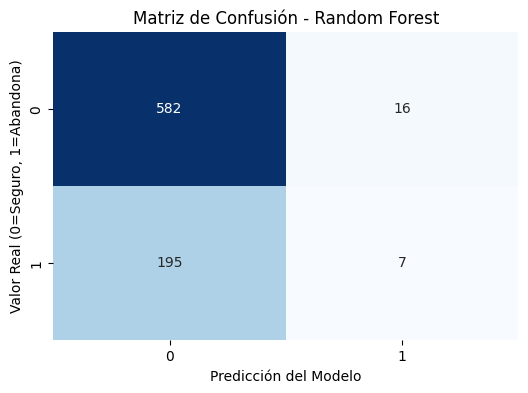


 RESULTADOS PARA: Red Neuronal Multicapa (con SMOTE)
Tiempo medio de inferencia: 62.7358 milisegundos

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.93       598
           1       0.79      0.76      0.77       202

    accuracy                           0.89       800
   macro avg       0.85      0.85      0.85       800
weighted avg       0.89      0.89      0.89       800



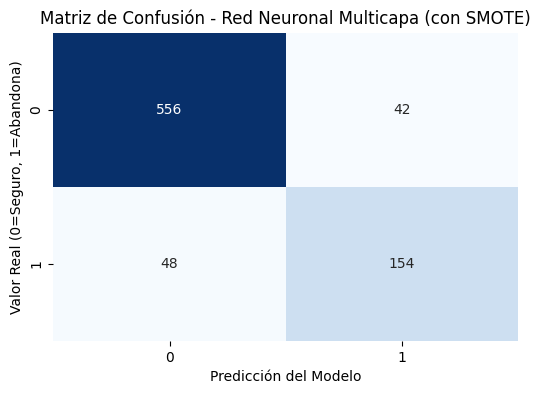

In [14]:
modelo.train() 
epocas = 150
for epoch in range(epocas):
    optimizador.zero_grad()
    predicciones = modelo(X_train_tensor)
    loss = criterio(predicciones, y_train_tensor)
    loss.backward()
    optimizador.step()

#
def evaluar_modelo(nombre, y_true, y_pred, tiempos_inferencia):
    print(f"\n{'='*40}")
    print(f" RESULTADOS PARA: {nombre}")
    print(f"{'='*40}")
    
    print(f"Tiempo medio de inferencia: {np.mean(tiempos_inferencia)*1000:.4f} milisegundos")
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Matriz de Confusión - {nombre}')
    plt.ylabel('Valor Real (0=Seguro, 1=Abandona)')
    plt.xlabel('Predicción del Modelo')
    plt.show()

inicio_rf = time.time()
y_pred_rf = rf_model.predict(X_test)
fin_rf = time.time()
evaluar_modelo("Random Forest", y_test, y_pred_rf, [fin_rf - inicio_rf])

modelo.eval()  

inicio_nn = time.time()
with torch.no_grad():
    logits_test = modelo(X_test_tensor)
    y_pred_nn = torch.argmax(logits_test, dim=1).numpy()
    
fin_nn = time.time()
evaluar_modelo("Red Neuronal Multicapa (con SMOTE)", y_test, y_pred_nn, [fin_nn - inicio_nn])